In [2]:
import numpy as np
import matplotlib.pyplot as plt
import astropy 
from scipy.stats import gaussian_kde
import astropy.units as u
from astropy.constants import M_sun
from astropy.constants import c
from astropy.constants import L_sun
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18 as cosmo
from astropy.constants import L_sun
L_sun_eps = L_sun.cgs.value


/beegfs/general/kprofit/binary_tests/ic_gen/ics_single_bh_3_nocgm_000.hdf5


(1485.0, 1515.0)

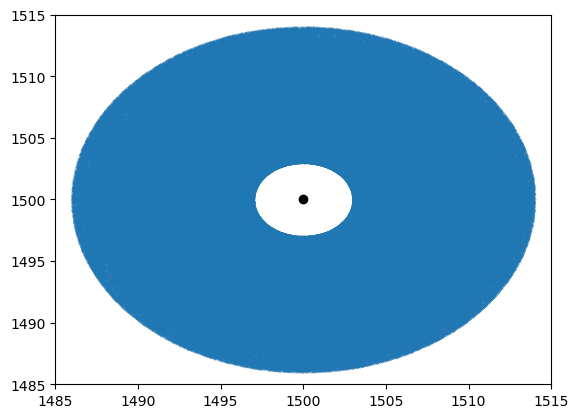

In [3]:
import sys
#sys.path.insert(0, '/mnt/home/skoudmani/for_kasar/python_scripts/')
sys.path.insert(0, '/soft/python3/usr/local/lib64/python3.9/site-packages') #import default cluster packages
sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/') #import custom packages
import read_snap_files as rsf
snapshot_path = '/beegfs/general/kprofit/binary_tests/ic_gen' 
snap_name = rsf.get_snap_filename(snapshot_path, 0, snap_prefix='ics_single_bh_3_nocgm')
gas_coords = rsf.get_snap_data(snap_name, 0, 'Coordinates')
masses = rsf.get_snap_data(snap_name, 0, 'Masses')
BH_coords = rsf.get_snap_data(snap_name, 5, 'Coordinates')
BH_masses = rsf.get_snap_data(snap_name, 5, 'Masses')

x_coords = gas_coords[:,0]
y_coords = gas_coords[:,1] 
z_coords = gas_coords[:,2]



BH_x_coords = BH_coords[:,0]
BH_y_coords = BH_coords[:,1]

com = np.average(BH_coords,weights=BH_masses,axis=0) #calculate center of mass
gas_adj = gas_coords - com

print(snap_name)
plt.scatter(x_coords,y_coords, s=0.01)
plt.scatter(BH_x_coords,BH_y_coords, color = 'black')
plt.xlim(1485,1515)
plt.ylim(1485,1515)

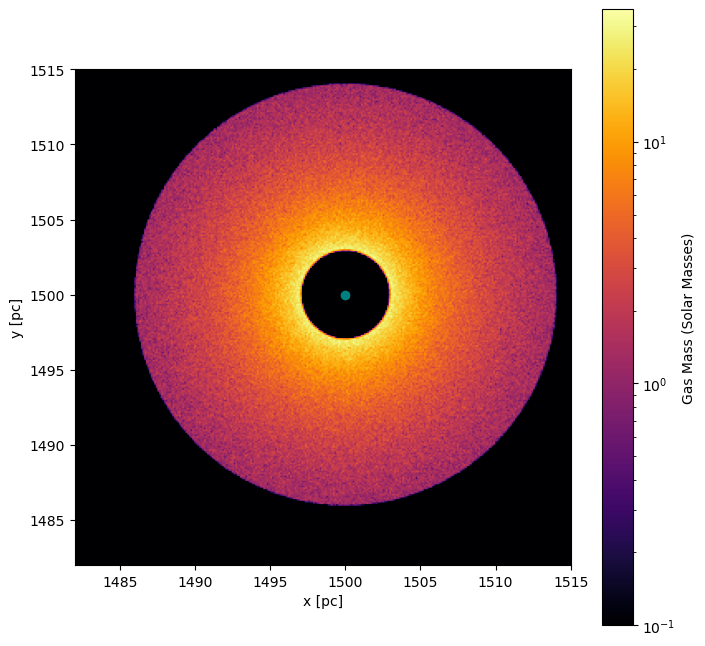

In [ ]:
from matplotlib.colors import LogNorm

x_coords = gas_coords[:,0]
y_coords = gas_coords[:,1] 

BH_x_coords = BH_coords[:,0]
BH_y_coords = BH_coords[:,1]

nbins = 300
x_edges = np.linspace(1482,1515, nbins+1)
y_edges = np.linspace(1482,1515, nbins+1)

image, _, _ = np.histogram2d(x_coords, y_coords, bins=[x_edges, y_edges], weights=masses)
image[image <= 0] = 1e-1  # Adjust this floor if needed

plt.figure(figsize=(8, 8))
plt.imshow(image.T, origin='lower', extent=[1482, 1515, 1482, 1515], cmap='inferno', norm=LogNorm())
plt.colorbar(label="Gas Mass (Solar Masses)")
plt.scatter(BH_x_coords,BH_y_coords, color = 'teal')

plt.xlabel("x [pc]")
plt.ylabel('y [pc]')

#plt.savefig("singleBH_2D_hist_mpl.png", bbox_inches="tight",dpi=800)
plt.show()
